In [1]:
#loading the dataset

In [83]:
import torch 
import torchvision
from torchvision import datasets
import torch.optim as optim
from torchvision import transforms as T 
from torch.utils.data import DataLoader, random_split

In [84]:
dataset_path = r"C:\Users\kanak\Downloads\UCMerced_LandUse\UCMerced_LandUse\Images"

transform = T.Compose([
    T.Resize((256, 256)),
    T.RandomHorizontalFlip(),
    # Resize images to 256x256
    T.ToTensor(),           # Convert images to PyTorch tensors
    T.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])  # Normalize to [-1,1] range
])

dataset = datasets.ImageFolder(root=dataset_path, transform=transform)


In [85]:
dataset


Dataset ImageFolder
    Number of datapoints: 2100
    Root location: C:\Users\kanak\Downloads\UCMerced_LandUse\UCMerced_LandUse\Images
    StandardTransform
Transform: Compose(
               Resize(size=(256, 256), interpolation=bilinear, max_size=None, antialias=True)
               RandomHorizontalFlip(p=0.5)
               ToTensor()
               Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
           )

In [86]:
print("Class names:", dataset.classes)
print("Number of images:", len(dataset))


Class names: ['agricultural', 'airplane', 'baseballdiamond', 'beach', 'buildings', 'chaparral', 'denseresidential', 'forest', 'freeway', 'golfcourse', 'harbor', 'intersection', 'mediumresidential', 'mobilehomepark', 'overpass', 'parkinglot', 'river', 'runway', 'sparseresidential', 'storagetanks', 'tenniscourt']
Number of images: 2100


In [87]:
total_size = len(dataset)
train_size = int(0.7 * total_size)
val_size = int(0.15 * total_size)
test_size = total_size - train_size - val_size 

# Set a random seed for reproducibility
torch.manual_seed(42)

# Split the dataset
train_dataset, val_dataset, test_dataset = random_split(dataset, [train_size, val_size, test_size])

# Print sizes
print(f"Train samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")
print(f"Test samples: {len(test_dataset)}")


Train samples: 1470
Validation samples: 315
Test samples: 315


In [88]:
batch_size = 32

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)


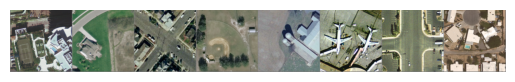

In [89]:
import matplotlib.pyplot as plt
import numpy as np

# Get one batch of images
dataiter = iter(train_loader)
images, labels = next(dataiter)

# Convert tensor image to numpy for plotting
def imshow(img):
    img = img / 2 + 0.5  # Unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.axis("off")
    plt.show()

# Show a batch of images
imshow(torchvision.utils.make_grid(images[:8]))  # Display first 8 images in the batch


In [90]:
if torch.cuda.is_available():
    device=torch.device(type="cuda",index=0)
else:
    device=torch.device(type="cpu",index=0)

print(device)

cpu:0


In [91]:
next(iter(train_loader))

[tensor([[[[-0.2078, -0.3255, -0.2471,  ..., -0.6706, -0.6392, -0.6471],
           [-0.4275, -0.4745, -0.4275,  ..., -0.6471, -0.6471, -0.6392],
           [-0.4980, -0.4980, -0.4745,  ..., -0.6235, -0.6314, -0.6235],
           ...,
           [-0.4745, -0.4980, -0.5451,  ..., -0.5059, -0.4510, -0.4275],
           [-0.5529, -0.5765, -0.6314,  ..., -0.4745, -0.4275, -0.3961],
           [-0.5451, -0.6235, -0.6235,  ..., -0.4980, -0.4745, -0.4745]],
 
          [[-0.2235, -0.3098, -0.2784,  ..., -0.6235, -0.6549, -0.6314],
           [-0.3882, -0.4039, -0.3569,  ..., -0.6314, -0.6314, -0.6549],
           [-0.4667, -0.4431, -0.3725,  ..., -0.6078, -0.5843, -0.6078],
           ...,
           [-0.3882, -0.4431, -0.4431,  ..., -0.3725, -0.3333, -0.3490],
           [-0.3882, -0.4118, -0.4431,  ..., -0.3882, -0.3020, -0.3333],
           [-0.4431, -0.4902, -0.4902,  ..., -0.3961, -0.3882, -0.3882]],
 
          [[-0.1843, -0.2235, -0.1922,  ..., -0.5373, -0.5608, -0.5451],
           [-

In [92]:
import torch.nn as nn
import torch.nn.functional as F

class LandUseCNN(nn.Module):
    def __init__(self, num_classes=21):
        super(LandUseCNN, self).__init__()
        
        self.conv_block1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),  # [3, 256, 256] -> [32, 256, 256]
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2)  # [32, 256, 256] -> [32, 128, 128]
        )

        self.conv_block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),  # [64, 128, 128]
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2)  # [64, 64, 64]
        )

        self.conv_block3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),  # [128, 64, 64]
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2)  # [128, 32, 32]
        )

        self.conv_block4 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, padding=1),  # [256, 32, 32]
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2)  # [256, 16, 16]
        )

        self.fc = nn.Sequential(
            nn.Flatten(),  # [256, 16, 16] -> [256*16*16]
            nn.Linear(256 * 16 * 16, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.conv_block1(x)
        x = self.conv_block2(x)
        x = self.conv_block3(x)
        x = self.conv_block4(x)
        x = self.fc(x)
        return x


In [93]:
model = LandUseCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [98]:

def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=10):
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        correct_train = 0
        total_train = 0

        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)

            # 🔥 Accuracy part
            _, predicted = torch.max(outputs, 1)
            total_train += labels.size(0)
            correct_train += (predicted == labels).sum().item()

        # 🔐 After epoch
        epoch_loss = running_loss / len(train_loader.dataset)
        epoch_acc = correct_train / total_train

        history['train_loss'].append(epoch_loss)
        history['train_acc'].append(epoch_acc)

        # 🧪 Validation
        model.eval()
        val_loss = 0.0
        correct = 0
        total = 0
        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * images.size(0)

                _, predicted = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        val_loss /= len(val_loader.dataset)
        val_acc = correct / total
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        print(f"Epoch {epoch+1}/{num_epochs} - "
              f"Train Loss: {epoch_loss:.4f}, Train Acc: {epoch_acc:.4f}, "
              f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

    return history

history_scratch = train_model(model, train_loader, val_loader, criterion, optimizer)


Epoch 1/10 - Train Loss: 14.5678, Train Acc: 0.1014, Val Loss: 2.8508, Val Acc: 0.1079
Epoch 2/10 - Train Loss: 2.8291, Train Acc: 0.1313, Val Loss: 2.5850, Val Acc: 0.2254
Epoch 3/10 - Train Loss: 2.8244, Train Acc: 0.1299, Val Loss: 2.7054, Val Acc: 0.2254
Epoch 4/10 - Train Loss: 2.7319, Train Acc: 0.1823, Val Loss: 2.5944, Val Acc: 0.2190
Epoch 5/10 - Train Loss: 2.6996, Train Acc: 0.1844, Val Loss: 2.4784, Val Acc: 0.2476
Epoch 6/10 - Train Loss: 2.6064, Train Acc: 0.2041, Val Loss: 2.4258, Val Acc: 0.2444
Epoch 7/10 - Train Loss: 2.6476, Train Acc: 0.1986, Val Loss: 2.5228, Val Acc: 0.2349
Epoch 8/10 - Train Loss: 2.5673, Train Acc: 0.2122, Val Loss: 2.3720, Val Acc: 0.2889
Epoch 9/10 - Train Loss: 2.5512, Train Acc: 0.2122, Val Loss: 2.4432, Val Acc: 0.2762
Epoch 10/10 - Train Loss: 2.5483, Train Acc: 0.2204, Val Loss: 2.3442, Val Acc: 0.2889


In [99]:
print(history_scratch['train_loss'])


[14.567771484089546, 2.8291375056416, 2.8243666992706506, 2.731944062758465, 2.6996334247848615, 2.606365139630376, 2.6476215008975696, 2.567282482393745, 2.5511678770285884, 2.5482930235311287]


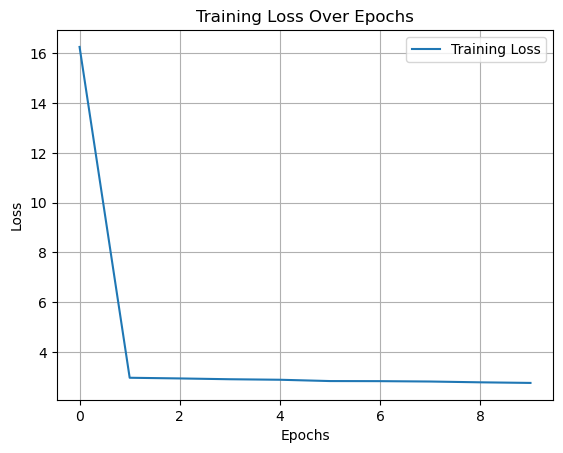

In [96]:
import matplotlib.pyplot as plt

plt.plot(history_scratch['train_loss'], label='Training Loss')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training Loss Over Epochs")
plt.legend()
plt.grid(True)
plt.show()


In [97]:
def evaluate_model(model, test_loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = correct / total
    print(f"Test Accuracy: {accuracy:.4f}")

evaluate_model(model, test_loader)


Test Accuracy: 0.0508


In [28]:
# import torch
# import torch.nn as nn

# class DRNN(nn.Module):
#     def __init__(self, num_classes=21):
#         super().__init__()
        
#         self.relu = nn.ReLU()
        
#         # Convolutional Layers
#         self.conv1 = nn.Conv2d(3, 8, kernel_size=(3,3), stride=1, padding=0)  # 256 -> 254
#         self.bn1 = nn.BatchNorm2d(8)
#         self.mp1 = nn.MaxPool2d(kernel_size=(2,2), stride=2, padding=0)  # 254 -> 127
        
#         self.conv2 = nn.Conv2d(8, 16, kernel_size=(3,3), stride=1, padding=0)  # 127 -> 125
#         self.bn2 = nn.BatchNorm2d(16)
        
#         self.conv3 = nn.Conv2d(16, 32, kernel_size=(3,3), stride=1, padding=0)  # 125 -> 123
#         self.bn3 = nn.BatchNorm2d(32)

#         self.conv4 = nn.Conv2d(32, 16, kernel_size=(3,3), stride=1, padding=0)  # 123 -> 121
#         self.bn4 = nn.BatchNorm2d(16)

#         self.flatten = nn.Flatten()
        
#         # Define Fully Connected Layer Later (Dynamic Calculation)
#         self.fc = None  # Placeholder
#         self.bn5 = None  # Placeholder
        
#         self.logsoftmax = nn.LogSoftmax(dim=1)  # Softmax for classification

#     def forward(self, x):
#         x = self.conv1(x)  # 3 -> 8, (256 -> 254)
#         x = self.relu(self.bn1(x))
        
#         x = self.conv2(x)  # 8 -> 16, (254 -> 252)
#         x = self.relu(self.bn2(x))
#         x = self.mp1(x)  # (252 -> 126)

#         x = self.conv3(x)  # 16 -> 32, (126 -> 124)
#         x = self.relu(self.bn3(x))

#         x = self.conv4(x)  # 32 -> 16, (124 -> 122)
#         x = self.relu(self.bn4(x))
#         x = self.mp1(x)  # (122 -> 61)

#         x = self.flatten(x)  # Flatten before FC
        
#         # Dynamically Initialize Fully Connected Layer
#         if self.fc is None:
#             in_features = x.shape[1]
#             self.fc = nn.Linear(in_features, 21).to(x.device)
#             self.bn5 = nn.BatchNorm1d(21).to(x.device)
        
#         x = self.fc(x)
#         x = self.bn5(x)
#         output = self.logsoftmax(x)
        
#         return output


In [29]:
# def train_one_epoch(dataloader, model,loss_fn, optimizer):
#     model.train()
#     track_loss=0
#     num_correct=0
#     for i, (imgs, labels) in enumerate(dataloader):
#         imgs=imgs.to(device)
#         labels=labels.to(device)
#         pred=model(imgs)

#         loss=loss_fn(pred,labels)
#         track_loss+=loss.item()
#         num_correct+=(torch.argmax(pred,dim=1)==labels).type(torch.float).sum().item()

#         running_loss=round(track_loss/(i+(imgs.shape[0]/batch_size)),2)
#         running_acc=round((num_correct/((i*batch_size+imgs.shape[0])))*100,2)

#         loss.backward()
#         optimizer.step()
#         optimizer.zero_grad()

#         if i%100==0:
#             print("Batch:", i+1, "/",len(dataloader), "Running Loss:",running_loss, "Running Accuracy:",running_acc)

#     epoch_loss=running_loss
#     epoch_acc=running_acc
#     return epoch_loss, epoch_acc

# def eval(dataloader, model,loss_fn, path):
#     model.eval()
#     with torch.no_grad():
#         for i, imgs in enumerate(dataloader):
#             imgs=imgs.to(device)
#             pred=model(imgs)

#             pred=torch.argmax(pred,dim=1).type(torch.int).cpu()
#             print(pred)

In [30]:
model=DRNN()
model=model.to(device)
loss_fn=nn.CrossEntropyLoss()
lr=0.001
#optimizer=torch.optim.SGD(params=model.parameters(), lr=lr)
optimizer=torch.optim.Adam(params=model.parameters(), lr=lr)
n_epochs=10

for i in range(n_epochs):
    print("Epoch No:",i+1)
    train_epoch_loss, train_epoch_acc=train_one_epoch(train_loader,model,loss_fn,optimizer)
    print("Training:", "Epoch Loss:", train_epoch_loss, "Epoch Accuracy:", train_epoch_acc)
    print("--------------------------------------------------")


Epoch No: 1
Batch: 1 / 53 Running Loss: 3.69 Running Accuracy: 9.38
Training: Epoch Loss: 3.3 Epoch Accuracy: 8.93
--------------------------------------------------
Epoch No: 2
Batch: 1 / 53 Running Loss: 3.15 Running Accuracy: 0.0
Training: Epoch Loss: 2.98 Epoch Accuracy: 13.39
--------------------------------------------------
Epoch No: 3
Batch: 1 / 53 Running Loss: 2.62 Running Accuracy: 21.88
Training: Epoch Loss: 2.85 Epoch Accuracy: 16.9
--------------------------------------------------
Epoch No: 4
Batch: 1 / 53 Running Loss: 2.69 Running Accuracy: 25.0
Training: Epoch Loss: 2.73 Epoch Accuracy: 20.42
--------------------------------------------------
Epoch No: 5
Batch: 1 / 53 Running Loss: 2.47 Running Accuracy: 28.12
Training: Epoch Loss: 2.59 Epoch Accuracy: 24.94
--------------------------------------------------
Epoch No: 6
Batch: 1 / 53 Running Loss: 2.45 Running Accuracy: 25.0
Training: Epoch Loss: 2.53 Epoch Accuracy: 25.06
---------------------------------------------